# K-Prototypes

In [ ]:
# import libraries
import pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes

# import pre-processed dataset
df = pd.read_csv("../data/processed/guns_encoded.csv")

# Drop useless columns
df = df.drop(columns=['S.No.', 'Year', 'Month', 'Date', 'Hispanic'], errors='ignore')

# Define feature groups
# Already one-hot encoded features
encoded_categorical = [
    'Reason_Accidental', 'Reason_Homicide', 'Reason_Suicide', 'Reason_Undetermined',
    'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 
    'Education_Some college', 'Education_Unknown',
    'Sex_Female', 'Sex_Male',
    'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 
    'Race_Native American/Native Alaskan', 'Race_White',
    'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction',
    'Place of incident_Other specified', 'Place of incident_Other unspecified', 
    'Place of incident_Residential institution', 'Place of incident_School/instiution',
    'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area',
    'Place of incident_Unspecified',
    'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 
    'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',
    'Police involvement', 'isWeekend' 
]

# Numerical features to scale (removed Month and Hispanic)
num_features = ["Age"]

# Combine all features for clustering
all_features = encoded_categorical + num_features
df_cluster = df[all_features].copy()

# --- Preprocess (only need to scale numerical features) ---
# Categorical features are already encoded, so no imputation/encoding needed
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

pre = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", "passthrough", encoded_categorical)
], remainder="drop")

# --- Pick K (elbow method) and fit K-Prototypes ---

# Prepare data for K-Prototypes (no preprocessing needed - use raw data)

# Reorder: numerical first, then categorical
ordered_cols = num_features + encoded_categorical
X_kproto = df_cluster[ordered_cols].values

# Handle missing values in Age (if any)
from sklearn.impute import SimpleImputer
age_imputer = SimpleImputer(strategy='median')
X_kproto[:, :len(num_features)] = age_imputer.fit_transform(X_kproto[:, :len(num_features)])

# Categorical features start after numerical ones
categorical_indices = list(range(len(num_features), X_kproto.shape[1]))

print(f"\nData shape: {X_kproto.shape}")
print(f"Numerical features: {len(num_features)} (indices 0-{len(num_features)-1})")
print(f"Categorical features: {len(encoded_categorical)} (indices {len(num_features)}-{X_kproto.shape[1]-1})")

# Find optimal K using cost (elbow method)
costs = []
K_range = range(2, 11)

print("\nFinding optimal K...")
for k in K_range:
    print(f"Testing K={k}...", end=" ")
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=3244, verbose=0, n_init=5)
    kproto.fit(X_kproto, categorical=categorical_indices)
    costs.append(kproto.cost_)
    print(f"Cost: {kproto.cost_:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'bo-', marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('K-Prototypes Elbow Method', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()




Data shape: (100798, 37)
Numerical features: 1 (indices 0-0)
Categorical features: 36 (indices 1-36)

Finding optimal K...
Testing K=2... Cost: 15346666.17
Testing K=3... Cost: 9492698.08
Testing K=4... Cost: 7437457.00
Testing K=5... Cost: 6466673.32
Testing K=6... Cost: 5933172.23
Testing K=7... Cost: 5574939.47
Testing K=8... 

## k = 4


Using K=4 clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 27848, ncost: 8639004.145741679
Run: 1, iteration: 2/100, moves: 11581, ncost: 8016168.573570898
Run: 1, iteration: 3/100, moves: 7411, ncost: 7790989.915331657
Run: 1, iteration: 4/100, moves: 5541, ncost: 7666527.790958659
Run: 1, iteration: 5/100, moves: 4245, ncost: 7594380.939913698
Run: 1, iteration: 6/100, moves: 3811, ncost: 7534699.970798528
Run: 1, iteration: 7/100, moves: 3175, ncost: 7491318.03694777
Run: 1, iteration: 8/100, moves: 2021, ncost: 7473659.60277574
Run: 1, iteration: 9/100, moves: 1724, ncost: 7461053.698058376
Run: 1, iteration: 10/100, moves: 106, ncost: 7460999.476160716
Run: 1, iteration: 11/100, moves: 0, ncost: 7460999.476160716
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 21317, ncost: 7690188.503824771
Run: 2, iteration: 2/100, moves: 7762, ncost: 7466878

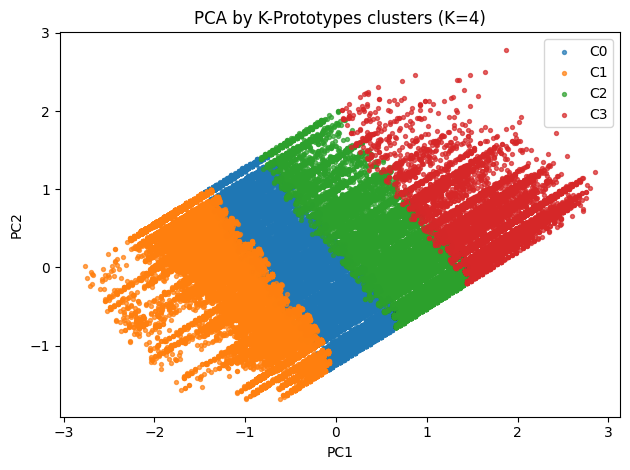


CLUSTER PROFILE FOR K=4

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 25,397 ( 25.2%)
Cluster 1: 33,301 ( 33.0%)
Cluster 2: 27,429 ( 27.2%)
Cluster 3: 14,671 ( 14.6%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        25397  39.90   40.0
1        33301  23.97   24.0
2        27429  57.09   57.0
3        14671  77.97   77.0

3. POLICE INVOLVEMENT DISTRIBUTION
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.981                   0.019
1                        0.981                   0.019
2                        0.991                   0.009
3                        0.998                   0.002

4. WEEKEND DISTRIBUTION
--------------------------------------------------
         Weekend=Weekday  Week

In [35]:
# Choose optimal K (you can adjust this based on the elbow plot)
best_k = 4  # Change this if you see a different elbow point

print(f"\nUsing K={best_k} clusters")

# Fit final K-Prototypes model
kproto_final = KPrototypes(n_clusters=best_k, init='Huang', random_state=3244, verbose=2, n_init=10)
labels = kproto_final.fit_predict(X_kproto, categorical=categorical_indices)

print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(labels)*100:.1f}%)")

# For PCA visualization, we need to standardize the data
# (K-Prototypes works on raw data, but PCA needs scaled data)
df_pre = pre.fit_transform(df_cluster)

# ============================================
# CLUSTER EVALUATION METRICS
# ============================================
print(f"\n{'='*60}")
print(f"CLUSTER EVALUATION METRICS")
print(f"{'='*60}")

# 1. Cost (from K-Prototypes)
print(f"K-Prototypes Cost: {kproto_final.cost_:.2f}")

# 2. Silhouette Score with Gower distance (for mixed data) **ran out of memory on large dataset**
# try:
#     import gower
#     distance_matrix = gower.gower_matrix(X_kproto)
#     silhouette_gower = silhouette_score(distance_matrix, labels, metric='precomputed')
#     print(f"Silhouette Score (Gower): {silhouette_gower:.4f} (range: -1 to 1, higher is better)")
# except ImportError:
#     print("Silhouette Score (Gower): Install 'gower' package to compute")

# 3. Davies-Bouldin Index (on preprocessed data)
db_score = davies_bouldin_score(df_pre, labels)
print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")

# 4. Calinski-Harabasz Score (on preprocessed data)
ch_score = calinski_harabasz_score(df_pre, labels)
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

print(f"\n{'='*60}")

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "cluster": labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster == c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend()
plt.title(f"PCA by K-Prototypes clusters (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Cluster Profile Table ---
# Create a summary dataframe with decoded categorical variables for interpretation
df_summary = df.copy()
df_summary["cluster"] = labels

# Decode one-hot encoded features back to categorical for profiling
df_summary["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
df_summary["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
df_summary["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
df_summary["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
df_summary["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
df_summary["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')
df_summary["Police_involvement"] = df_summary["Police involvement"].map({0: "No", 1: "Yes"})
df_summary["Weekend"] = df_summary["isWeekend"].map({0: "Weekday", 1: "Weekend"})

# Numerical summaries
num_summary = df_summary.groupby("cluster")[["Age"]].agg(["count", "mean", "median"]).round(2)

# Categorical proportion tables
def prop_table(data, col):

    tab = (data.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    
    tab.columns = [f"{col}={c}" for c in tab.columns]

    return tab.round(3)

cat_summary = pd.concat([
    prop_table(df_summary, "Race"),
    prop_table(df_summary, "Education"),
    prop_table(df_summary, "Place_of_incident"),
    prop_table(df_summary, "Reason"),
    prop_table(df_summary, "Day_of_week"),
    prop_table(df_summary, "Sex"),
    prop_table(df_summary, "Police_involvement"),
    prop_table(df_summary, "Weekend") 
], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()

# Print Cluster Profile
print("\n" + "="*70)
print(f"CLUSTER PROFILE FOR K={best_k}")
print("="*70)

# 1. Cluster Sizes
print("\n1. CLUSTER SIZES")
print("-" * 50)
cluster_sizes = df_summary['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    pct = (size / len(df_summary)) * 100
    print(f"Cluster {cluster}: {size:>6,} ({pct:>5.1f}%)")

# 2. Age Summary
print("\n2. AGE DISTRIBUTION")
print("-" * 50)
print(num_summary[['Age']])

# 3. Police Involvement (categorical proportions)
print("\n3. POLICE INVOLVEMENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Police_involvement='))

# 4. Weekend Pattern (categorical proportions)
print("\n4. WEEKEND DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Weekend='))

# 5. Race Distribution
print("\n5. RACE DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Race='))

# 6. Education Distribution
print("\n6. EDUCATION DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Education='))

# 7. Place of Incident
print("\n7. PLACE OF INCIDENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Place_of_incident='))

# 8. Reason Distribution
print("\n8. REASON DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Reason='))

# 9. Day of Week
print("\n9. DAY OF WEEK DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Day_of_week='))

# 10. Sex Distribution
print("\n10. SEX DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Sex='))

print("\n" + "="*70)

In [2]:
pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 80.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 8.7/8.7 MB 91.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -------------------------- ------------- 25.4/38.1 MB 124.0 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 101.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\Beckh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## k = 5

In [1]:
# Choose optimal K (you can adjust this based on the elbow plot)
best_k = 5  # Change this if you see a different elbow point

print(f"\nUsing K={best_k} clusters")

# Fit final K-Prototypes model
kproto_final = KPrototypes(n_clusters=best_k, init='Huang', random_state=3244, verbose=2, n_init=10)
labels = kproto_final.fit_predict(X_kproto, categorical=categorical_indices)

print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(labels)*100:.1f}%)")

# For evaluation metrics, we need to standardize the data
df_pre = pre.fit_transform(df_cluster)

# ============================================
# CLUSTER EVALUATION METRICS
# ============================================
print(f"\n{'='*60}")
print(f"CLUSTER EVALUATION METRICS")
print(f"{'='*60}")

# 1. Cost (from K-Prototypes)
print(f"K-Prototypes Cost: {kproto_final.cost_:.2f}")

# 2. Davies-Bouldin Index (on preprocessed data)
db_score = davies_bouldin_score(df_pre, labels)
print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")

# 3. Calinski-Harabasz Score (on preprocessed data)
ch_score = calinski_harabasz_score(df_pre, labels)
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

print(f"\n{'='*60}")

# ============================================
# UMAP VISUALIZATION
# ============================================
import umap

# UMAP with hamming metric for binary/one-hot encoded data
reducer = umap.UMAP(
    n_components=2,
    metric='hamming',
    n_neighbors=30,
    min_dist=0.1,
    random_state=3244
)

print("\nFitting UMAP (this may take a minute)...")
X_2d = reducer.fit_transform(df_pre)

# Plot UMAP
plt.figure(figsize=(10, 8))
for c in sorted(np.unique(labels)):
    mask = labels == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.5, label=f"Cluster {c}")

plt.legend(markerscale=3)
plt.title(f"UMAP Projection of K-Prototypes Clusters (K={best_k})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

# --- Cluster Profile Table ---
# Create a summary dataframe with decoded categorical variables for interpretation
df_summary = df.copy()
df_summary["cluster"] = labels

# Decode one-hot encoded features back to categorical for profiling
df_summary["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
df_summary["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
df_summary["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
df_summary["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
df_summary["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
df_summary["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')
df_summary["Police_involvement"] = df_summary["Police involvement"].map({0: "No", 1: "Yes"})
df_summary["Weekend"] = df_summary["isWeekend"].map({0: "Weekday", 1: "Weekend"})

# Numerical summaries
num_summary = df_summary.groupby("cluster")[["Age"]].agg(["count", "mean", "median"]).round(2)

# Categorical proportion tables
def prop_table(data, col):

    tab = (data.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    
    tab.columns = [f"{col}={c}" for c in tab.columns]

    return tab.round(3)

cat_summary = pd.concat([
    prop_table(df_summary, "Race"),
    prop_table(df_summary, "Education"),
    prop_table(df_summary, "Place_of_incident"),
    prop_table(df_summary, "Reason"),
    prop_table(df_summary, "Day_of_week"),
    prop_table(df_summary, "Sex"),
    prop_table(df_summary, "Police_involvement"),
    prop_table(df_summary, "Weekend") 
], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()

# Print Cluster Profile
print("\n" + "="*70)
print(f"CLUSTER PROFILE FOR K={best_k}")
print("="*70)

# 1. Cluster Sizes
print("\n1. CLUSTER SIZES")
print("-" * 50)
cluster_sizes = df_summary['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    pct = (size / len(df_summary)) * 100
    print(f"Cluster {cluster}: {size:>6,} ({pct:>5.1f}%)")

# 2. Age Summary
print("\n2. AGE DISTRIBUTION")
print("-" * 50)
print(num_summary[['Age']])

# 3. Police Involvement (categorical proportions)
print("\n3. POLICE INVOLVEMENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Police_involvement='))

# 4. Weekend Pattern (categorical proportions)
print("\n4. WEEKEND DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Weekend='))

# 5. Race Distribution
print("\n5. RACE DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Race='))

# 6. Education Distribution
print("\n6. EDUCATION DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Education='))

# 7. Place of Incident
print("\n7. PLACE OF INCIDENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Place_of_incident='))

# 8. Reason Distribution
print("\n8. REASON DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Reason='))

# 9. Day of Week
print("\n9. DAY OF WEEK DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Day_of_week='))

# 10. Sex Distribution
print("\n10. SEX DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Sex='))

print("\n" + "="*70)


Using K=5 clusters


NameError: name 'KPrototypes' is not defined

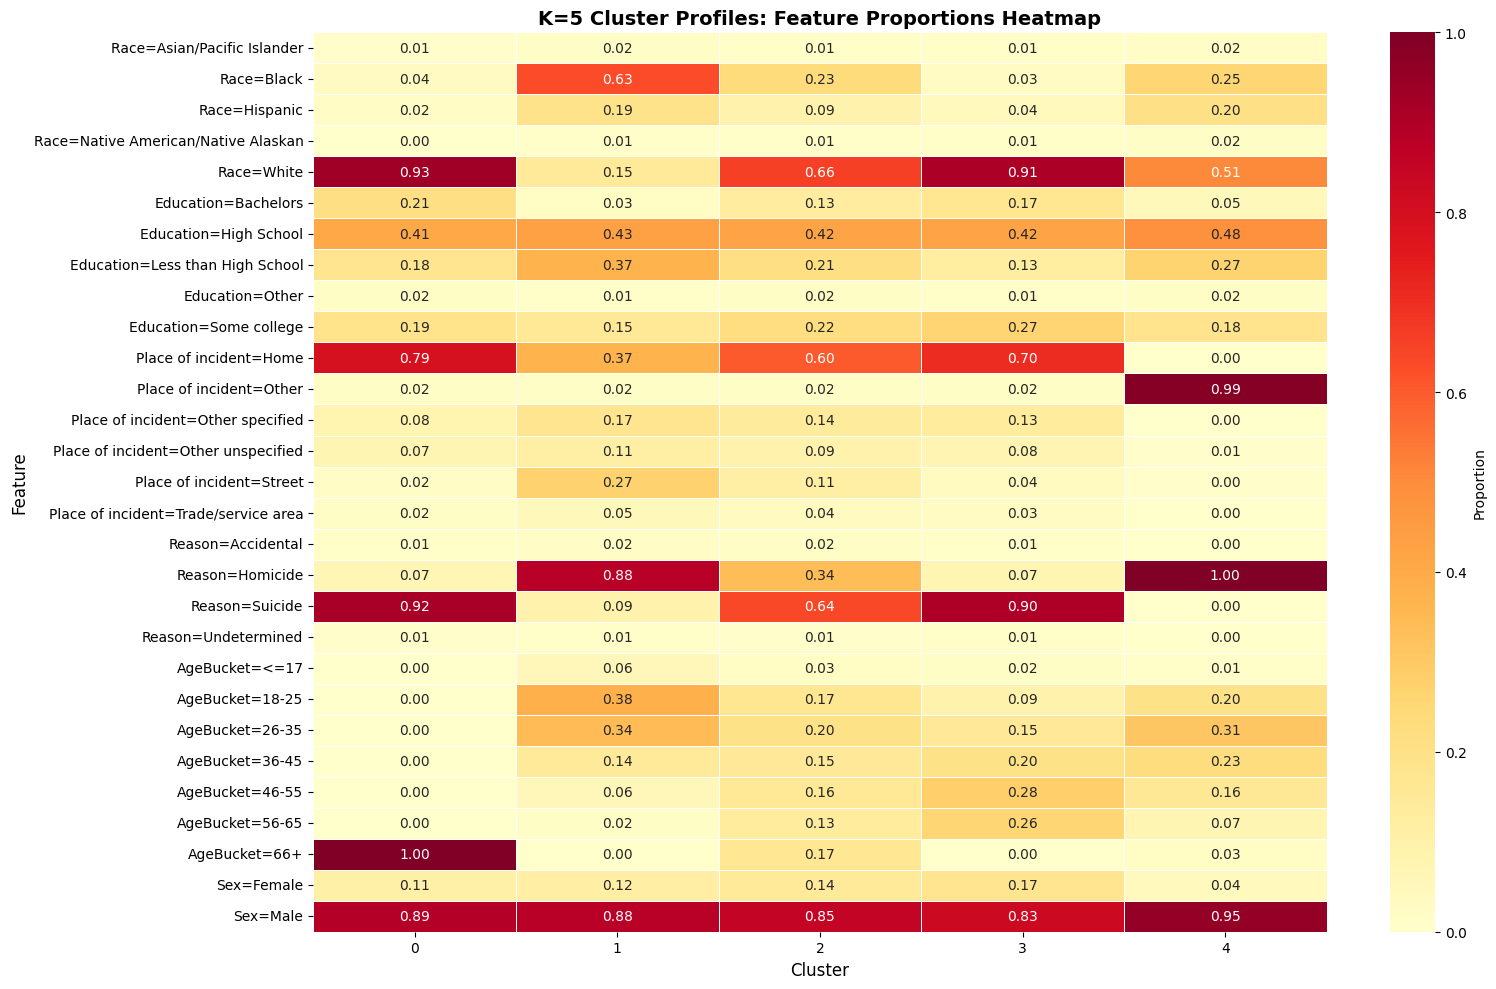

In [ ]:
import seaborn as sns

# Create heatmap for K=5 cluster profiles
plt.figure(figsize=(16, 10))
profile_viz_k5 = profile_5.iloc[:, 6:].T  # categorical features only (skip numerical summaries)

sns.heatmap(profile_viz_k5, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Proportion'}, linewidths=0.5)
plt.title('K=5 Cluster Profiles: Feature Proportions Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()